# Prediction Baselines: Points Averages

This notebook scores three simple baselines for predicting a player's points in a game. Each baseline uses a feature built in `feature_engineering.ipynb` as its prediction:

- **Season avg** (`pts_season_avg`): average points over prior games this season
- **Last 5 avg** (`pts_last5_avg`): average points over the prior 5 games
- **Last 10 avg** (`pts_last10_avg`): average points over the prior 10 games

Every baseline is scored with MAE, RMSE and R². An ML model has to beat these numbers on the same test rows to be worth using.

## Load the feature dataset

The dataset comes from `feature_engineering.ipynb` and already has a chronological `split` column (`train` / `test`).

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Locate the CSV from the notebook's folder or any parent (repo root).
DATA_RELATIVE_PATH = Path('data') / 'sample' / 'sample_player_game_logs_features.csv'
DATA_PATH = next(
    (root / DATA_RELATIVE_PATH for root in (Path.cwd(), *Path.cwd().parents) if (root / DATA_RELATIVE_PATH).exists()),
    None,
)
assert DATA_PATH is not None, f'Could not find {DATA_RELATIVE_PATH}; run feature_engineering.ipynb first'

BASELINES = {
    'Season avg': 'pts_season_avg',
    'Last 5 avg': 'pts_last5_avg',
    'Last 10 avg': 'pts_last10_avg',
}
TARGET = 'points'

features = pd.read_csv(DATA_PATH, dtype={'game_id': str}, parse_dates=['game_date'])
missing = {TARGET, 'split', *BASELINES.values()} - set(features.columns)
assert not missing, f'Missing columns: {missing}'

print(DATA_PATH)
print(features.shape)
features['split'].value_counts()

Matplotlib is building the font cache; this may take a moment.


/Users/swayamshree/Desktop/Capstone Project/CPSC491-02Group8SportsBetting/data/sample/sample_player_game_logs_features.csv
(43, 30)


split
train    34
test      9
Name: count, dtype: int64

## Metrics

- **MAE**: average absolute miss, in points
- **RMSE**: like MAE, but large misses count more; also in points
- **R²**: share of the variance in points the prediction explains (1 is perfect, 0 is no better than always predicting the mean, negative is worse)

In [3]:
def evaluate(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred),
    }

## Drop games with no history

A player's first game has no prior games, so its baseline features are `NaN`. Those rows are dropped so all three baselines are scored on exactly the same games.

In [4]:
scored = features.dropna(subset=list(BASELINES.values()))

dropped = features['split'].value_counts().sub(scored['split'].value_counts(), fill_value=0).astype(int)
print('Rows dropped per split:')
print(dropped.to_string())

Rows dropped per split:
split
train    1
test     0


## Score the baselines

The **test** rows are the headline numbers, because an ML model is scored on the same games. Train numbers are shown for reference.

In [5]:
rows = []
for split in ('train', 'test'):
    split_rows = scored[scored['split'] == split]
    for name, col in BASELINES.items():
        rows.append({'baseline': name, 'split': split, 'n': len(split_rows),
                     **evaluate(split_rows[TARGET], split_rows[col])})

results = pd.DataFrame(rows).round(3)
results[results['split'] == 'test'].sort_values('MAE').reset_index(drop=True)

,baseline,split,n,MAE,RMSE,R2
0,Last 10 avg,test,9,6.144,7.735,-0.047
1,Season avg,test,9,6.553,8.439,-0.246
2,Last 5 avg,test,9,7.267,9.634,-0.624


In [6]:
results[results['split'] == 'train'].sort_values('MAE').reset_index(drop=True)

,baseline,split,n,MAE,RMSE,R2
0,Season avg,train,33,8.838,11.510,-0.142
1,Last 10 avg,train,33,8.991,11.592,-0.158
2,Last 5 avg,train,33,8.995,11.856,-0.212


## Predicted vs. actual (test)

Points on the dashed line are perfect predictions. Points below the line mean the baseline under-predicted.

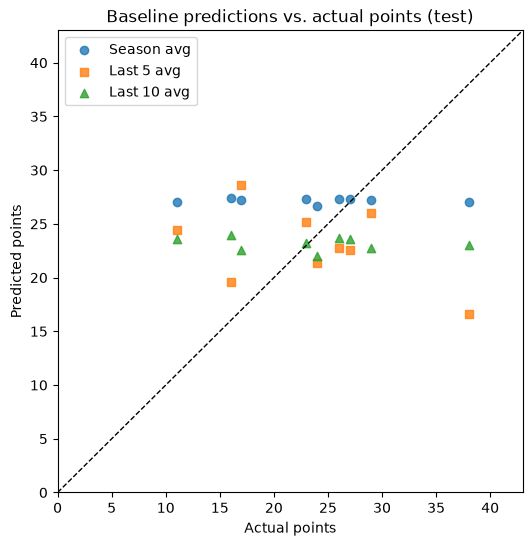

In [7]:
test = scored[scored['split'] == 'test']

fig, ax = plt.subplots(figsize=(6, 6))
for (name, col), marker in zip(BASELINES.items(), ('o', 's', '^')):
    ax.scatter(test[TARGET], test[col], label=name, marker=marker, alpha=0.8)

lims = [0, max(test[TARGET].max(), test[list(BASELINES.values())].max().max()) + 5]
ax.plot(lims, lims, 'k--', linewidth=1)
ax.set(xlim=lims, ylim=lims, xlabel='Actual points', ylabel='Predicted points',
       title='Baseline predictions vs. actual points (test)')
ax.legend()
plt.show()

## Notes

- MAE and RMSE are in points, and lower is better. R² is higher-is-better; a value at or below 0 means the baseline does no better than predicting the test-set mean.
- The sample test split is very small (only a few games), so these numbers are noisy. Re-run this notebook after the full dataset goes through `feature_engineering.ipynb` before drawing conclusions.

## Save the metrics (optional)

Set `SAVE_OUTPUT = True` to write the metrics table so model notebooks can load it for comparison. It is off by default so running the notebook does not create files.

In [8]:
SAVE_OUTPUT = True
OUTPUT_PATH = Path.cwd() / 'baseline_metrics.csv'

if SAVE_OUTPUT:
    results.to_csv(OUTPUT_PATH, index=False)
    print(f'Wrote {len(results)} rows to {OUTPUT_PATH}')
else:
    print(f'SAVE_OUTPUT is False; would write {len(results)} rows to {OUTPUT_PATH}')

Wrote 6 rows to /Users/swayamshree/Desktop/Capstone Project/CPSC491-02Group8SportsBetting/ml/EDA/baseline_metrics.csv
